**Now working to extract the parameters of GaNs to help us analyse QDs and make height thresholding estimates**

Since this file is no longer connected to the others, we need to ensure that the connections betweem all of them is still working. But we are still uploading things form the Detection notebook so that we can keep working with the destriped image.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

while not (
    (PROJECT_ROOT / "Detection").exists()
    and (PROJECT_ROOT / "Image-Preprocessing").exists()
):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

DETECTION_DIR = PROJECT_ROOT / "Detection"
PREPROCESSING_DIR = PROJECT_ROOT / "Image-Preprocessing"

CLASSICAL_DIR = DETECTION_DIR / "Classical-Optimised"
BIOLOGY_DIR = DETECTION_DIR / "Biology-Inspired"
CNN_DIR = DETECTION_DIR / "Binary-CNN-Model"
GROUND_TRUTH_DIR = PROJECT_ROOT / "Ground-Truth"

for path in [
    PROJECT_ROOT,
    DETECTION_DIR,
    PREPROCESSING_DIR,
    CLASSICAL_DIR,
    BIOLOGY_DIR,
    CNN_DIR,
    GROUND_TRUTH_DIR,
]:
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import preprocessing_metrics as pm

import detection_algorithms as da
import detection_errors as de

import QD_analysis as qa

In [7]:
DATA_DIR = PROJECT_ROOT / "Data-Conversion"
GT_DATA_DIR = GROUND_TRUTH_DIR / "NPY-Ground-Truth"

SCAN_DIRS = {
    "Scan1": GT_DATA_DIR / "Scan1",
    "Scan2": GT_DATA_DIR / "Scan2",
    "Scan3": GT_DATA_DIR / "Scan3",
}

1. Upload and preprocess the data

In [33]:
raw_scans = []
processed_scans = []
ground_truth_masks = []

for scan_name in ["Scan1", "Scan2", "Scan3"]:
    scan_dir = SCAN_DIRS[scan_name]

    raw = np.load(scan_dir / "channel_00___0_data.npy")

    mask = np.load(scan_dir / "channel_00___0_data_mask.npy")

    processed, stages = bdp.preprocess_afm(
        raw,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    raw_scans.append(raw)
    processed_scans.append(processed)
    ground_truth_masks.append(mask)

In [34]:
from skimage.measure import label, regionprops


def centres_from_binary_mask(binary_mask):
    binary_mask = np.asarray(binary_mask, dtype=bool)
    labelled_mask = label(binary_mask, connectivity=2)

    centres = [region.centroid for region in regionprops(labelled_mask)]

    if not centres:
        return np.empty((0, 2), dtype=float)

    return np.asarray(centres, dtype=float)


dataset = {}

for scan_name, raw, processed, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    processed_scans,
    ground_truth_masks,
):
    dataset[scan_name] = {
        "raw": raw,
        "processed": processed,
        "ground_truth_mask": mask,
        "ground_truth_centres": centres_from_binary_mask(mask),
    }

Sanity-check (because sometimes notebooks kept forgetting about the variables..)

In [35]:
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Detection algorithms:", CLASSICAL_DIR.exists())
print("Preprocessing:", PREPROCESSING_DIR.exists())
print("Ground truth:", GROUND_TRUTH_DIR.exists())

print(dataset.keys())

for scan_name, data in dataset.items():
    print(
        scan_name,
        data["raw"].shape,
        data["ground_truth_mask"].shape,
        len(data["ground_truth_centres"]),
    )

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis
Detection algorithms: True
Preprocessing: True
Ground truth: True
dict_keys(['Scan1', 'Scan2', 'Scan3'])
Scan1 (512, 512) (512, 512) 133
Scan2 (512, 512) (512, 512) 137
Scan3 (512, 512) (512, 512) 135


**Preprocess Scan 3:**

In [24]:
scan_name = "Scan3"
scan_dir = GROUND_TRUTH_DIR / "NPY-Ground-Truth" / scan_name

z = np.load(scan_dir / "channel_00___0_data.npy")
ground_truth_mask = np.load(scan_dir / "channel_00___0_data_mask.npy")

z_processed, stages = bdp.preprocess_afm(
    z,
    remove_plane=True,
    line_flatten=True,
    align_rows=True,
    remove_2d_background=False,
)

ground_truth_centres = centres_from_binary_mask(ground_truth_mask)

# GaN layer detection

In [25]:
from scipy.ndimage import uniform_filter

from skimage.filters import (threshold_otsu, threshold_sauvola, threshold_li, threshold_yen,)
from skimage.measure import label, regionprops
from skimage.morphology import (binary_closing, binary_dilation, disk, remove_small_objects,)

**1. Heavy smoothing: suppress QDs and retain broad GaNs**

In [26]:
GaN_sigma = 6

z_GaN_smooth = gaussian_filter(z_processed, sigma=GaN_sigma, mode="reflect",)
finite = np.isfinite(z_GaN_smooth)

# Normalize to [0, 1] for thresholding
z_min = np.nanmin(z_GaN_smooth)
z_max = np.nanmax(z_GaN_smooth)

z_GaN_norm = (z_GaN_smooth - z_min) / (z_max - z_min + 1e-12)

**2. Threshold dark GaNs**

In [27]:
# Global Otsu
otsu_threshold = threshold_otsu(z_GaN_norm[finite])
mask_otsu = (z_GaN_norm < otsu_threshold) & finite


# Local Sauvola
local_window = 51  # Must be odd
sauvola_threshold = threshold_sauvola(z_GaN_norm, window_size=local_window, k=0.15,)
mask_sauvola = (z_GaN_norm < sauvola_threshold) & finite


# Local Phansalkar
phansalkar_k = 0.25
phansalkar_r = 0.5
phansalkar_p = 2.0
phansalkar_q = 10.0

local_mean = uniform_filter(z_GaN_norm, size=local_window, mode="reflect",)
local_mean_squared = uniform_filter(z_GaN_norm**2, size=local_window, mode="reflect",)
local_std = np.sqrt(np.maximum(local_mean_squared - local_mean**2, 0,))

phansalkar_threshold = local_mean * (1 + phansalkar_p* np.exp(-phansalkar_q * local_mean)+ phansalkar_k* (local_std / phansalkar_r - 1))
mask_phansalkar = (z_GaN_norm < phansalkar_threshold) & finite


# Other global thresholds
li_threshold = threshold_li(z_GaN_norm[finite])
mask_li = (z_GaN_norm < li_threshold) & finite

yen_threshold = threshold_yen(z_GaN_norm[finite])
mask_yen = (z_GaN_norm < yen_threshold) & finite

**3. Keep objects within the required area range**

In [28]:
minimum_area = 8
maximum_area = 2500

raw_masks = {
    "Otsu": mask_otsu,
    "Sauvola": mask_sauvola,
    "Phansalkar": mask_phansalkar,
    "Li": mask_li,
    "Yen": mask_yen,
}

filtered_masks = {}

for name, raw_mask in raw_masks.items():
    cleaned = remove_small_objects(raw_mask, min_size=minimum_area,)
    cleaned = binary_closing(cleaned, footprint=disk(1),)
    labelled_image = label(cleaned)
    filtered_mask = np.zeros_like(cleaned, dtype=bool,)

    for region in regionprops(labelled_image):
        if minimum_area <= region.area <= maximum_area:
            filtered_mask[labelled_image == region.label] = True

    filtered_masks[name] = filtered_mask

1641728324.py (15): Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
1641728324.py (16): `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
1641728324.py (15): Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
1641728324.py (16): `binary_closing` is deprecated since version 0.

**4. Compare thresholding methods**

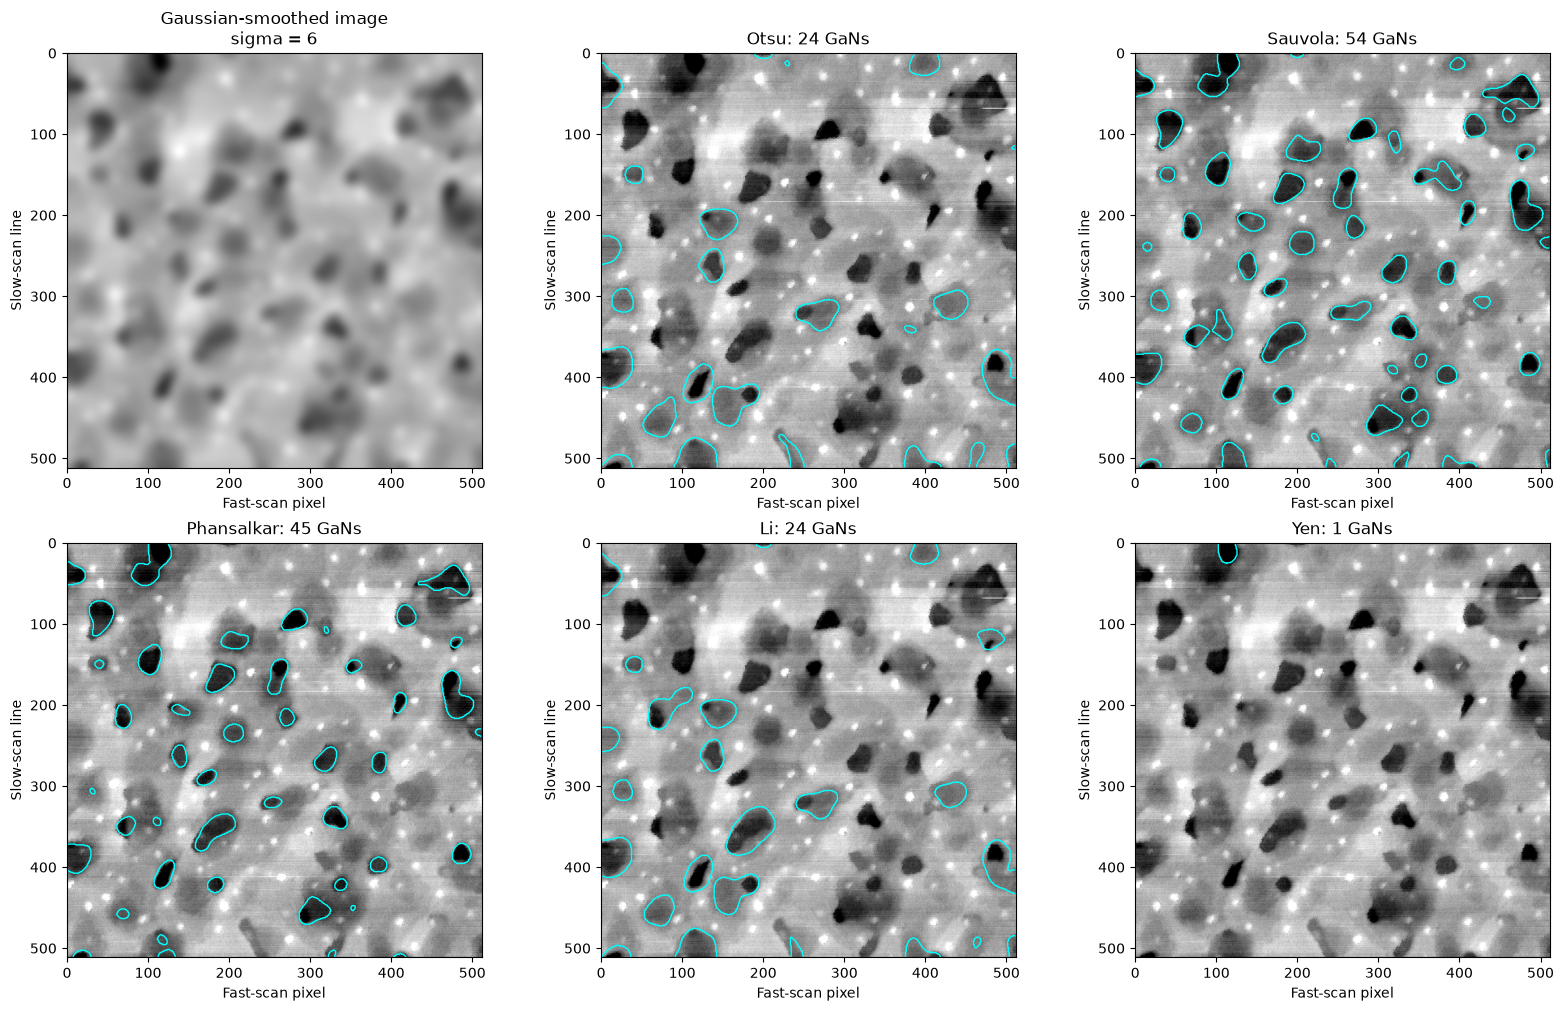

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

axes[0, 0].imshow(z_GaN_smooth, cmap="gray",)

axes[0, 0].set_title(
    f"Gaussian-smoothed image\n"
    f"sigma = {GaN_sigma}"
)

method_names = ["Otsu", "Sauvola", "Phansalkar", "Li", "Yen",]
display_vmin, display_vmax = np.nanpercentile(z_processed, [1, 99],)

for ax, method_name in zip( axes.ravel()[1:], method_names,):
    current_mask = filtered_masks[method_name]
    current_labels = label(current_mask)

    ax.imshow(z_processed, cmap="gray", vmin=display_vmin, vmax=display_vmax,)
    ax.contour(current_mask, levels=[0.5], colors="cyan", linewidths=1,)
    ax.set_title(
        f"{method_name}: "
        f"{current_labels.max()} GaNs"
    )

for ax in axes.ravel():
    ax.set_xlabel("Fast-scan pixel")
    ax.set_ylabel("Slow-scan line")

plt.show()

**5. Select the preferred method**

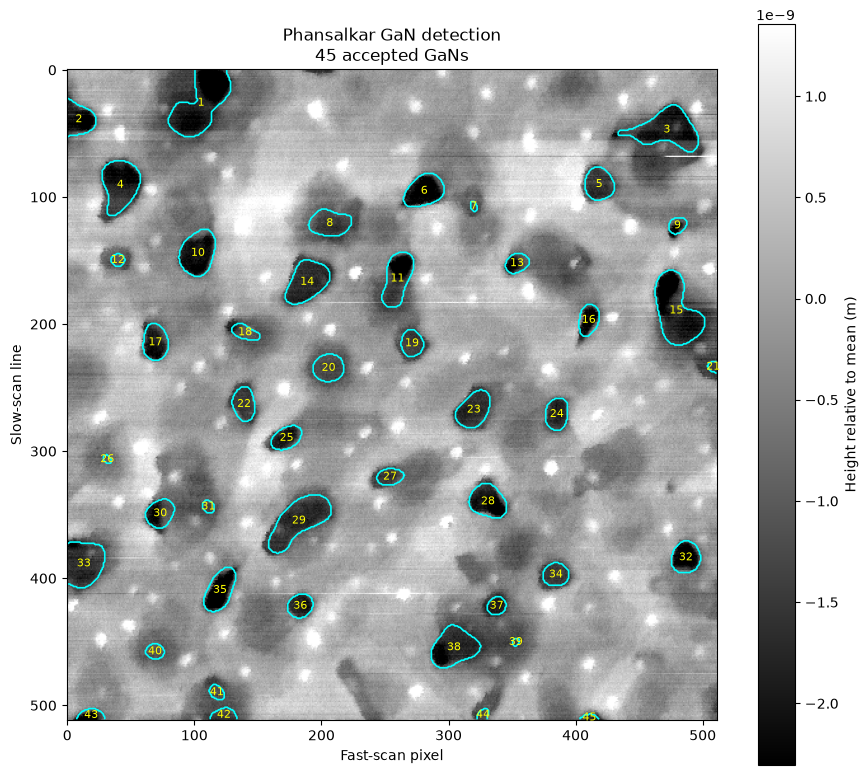

In [31]:
chosen_method = "Phansalkar"
GaN_mask = filtered_masks[chosen_method]
GaN_labels = label(GaN_mask)
GaN_regions = regionprops(GaN_labels)

fig, ax = plt.subplots(figsize=(9, 8))

image_display = ax.imshow(
    z_processed,
    cmap="gray",
    vmin=display_vmin,
    vmax=display_vmax,
)

ax.contour(GaN_mask, levels=[0.5], colors="cyan", linewidths=1.2,)

for region in regionprops(GaN_labels):
    y, x = region.centroid
    ax.text(x, y, str(region.label), color="yellow", fontsize=8, ha="center", va="center",)

ax.set_title(
    f"{chosen_method} GaN detection\n"
    f"{len(GaN_regions)} accepted GaNs"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")

fig.colorbar(image_display, ax=ax, label="Height relative to mean (m)")

plt.tight_layout()
plt.show()

**6. Measure GaN height/depth**

In [32]:
background_ring_width = 8
measurements = []

for region in regionprops(GaN_labels):

    individual_GaN = (GaN_labels == region.label)
    expanded_GaN = binary_dilation(individual_GaN, footprint=disk(background_ring_width))
    local_background_ring = (expanded_GaN & ~individual_GaN & np.isfinite(z_processed))

    GaN_values = z_processed[individual_GaN]
    background_values = z_processed[local_background_ring]

    if (GaN_values.size == 0 or background_values.size < 10):
        continue

    local_surface = np.nanmedian(background_values)
    minimum_height = np.nanmin(GaN_values)
    median_height = np.nanmedian(GaN_values)
    mean_height = np.nanmean(GaN_values)
    maximum_depth = (local_surface - minimum_height)
    median_depth = (local_surface - median_height)

    mean_depth = (local_surface - mean_height)

    centroid_y, centroid_x = (region.centroid)

    measurements.append(
        {
            "GaN_id": region.label,
            "centroid_y": centroid_y,
            "centroid_x": centroid_x,
            "area_pixels": region.area,
            "equivalent_diameter_pixels":
                region.equivalent_diameter_area,
            "major_axis_pixels":
                region.axis_major_length,
            "minor_axis_pixels":
                region.axis_minor_length,
            "maximum_depth_m":
                maximum_depth,
            "median_depth_m":
                median_depth,
            "mean_depth_m":
                mean_depth,
            "maximum_depth_nm":
                maximum_depth * 1e9,
            "median_depth_nm":
                median_depth * 1e9,
            "mean_depth_nm":
                mean_depth * 1e9,
        }
    )


# 7. Print measurements

print("Threshold method:", chosen_method,)
print("Number of detected GaNs:", len(measurements),)

for GaN in measurements:
    print(f"\nGaN {GaN['GaN_id']}")
    print("  Centroid:", (round(GaN["centroid_y"], 2), round(GaN["centroid_x"], 2),),)
    print("  Area:", GaN["area_pixels"], "pixels",)
    print( "  Equivalent diameter:", round(GaN["equivalent_diameter_pixels"], 2,),"pixels",)
    print("  Maximum depth:", round(GaN["maximum_depth_nm"], 3,), "nm",)
    print("  Median depth:", round(GaN["median_depth_nm"], 3,), "nm",)

1661418990.py (7): `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).


Threshold method: Phansalkar
Number of detected GaNs: 45

GaN 1
  Centroid: (np.float64(25.96), np.float64(105.31))
  Area: 1453.0 pixels
  Equivalent diameter: 43.01 pixels
  Maximum depth: 2.642 nm
  Median depth: 0.904 nm

GaN 2
  Centroid: (np.float64(38.91), np.float64(9.19))
  Area: 491.0 pixels
  Equivalent diameter: 25.0 pixels
  Maximum depth: 2.976 nm
  Median depth: 1.779 nm

GaN 3
  Centroid: (np.float64(47.08), np.float64(471.87))
  Area: 1157.0 pixels
  Equivalent diameter: 38.38 pixels
  Maximum depth: 1.989 nm
  Median depth: 1.027 nm

GaN 4
  Centroid: (np.float64(90.48), np.float64(41.77))
  Area: 916.0 pixels
  Equivalent diameter: 34.15 pixels
  Maximum depth: 2.309 nm
  Median depth: 1.493 nm

GaN 5
  Centroid: (np.float64(89.88), np.float64(418.57))
  Area: 466.0 pixels
  Equivalent diameter: 24.36 pixels
  Maximum depth: 1.818 nm
  Median depth: 1.244 nm

GaN 6
  Centroid: (np.float64(95.22), np.float64(280.94))
  Area: 610.0 pixels
  Equivalent diameter: 27.87 p

So, now we have 2 classes of object that code is able to detect. The rest of the analysis of separating and analysing GaN crystal and QD are presented in the analysis file.

# Detecting QDs within and outside the GaN layer

**Algorithm for GaN detection** 

1. Blur the background so that no small features get detected (gaussian smoothing with a high standard deviation)

2. Only allow features between 20-150 pixels to ramain and apply other thresholding techniques like:
    2.1 Otsu
    2.2 Sauvola
    2.3 Phansaulkar 
    2.4 Others?

3. Measure height at the different positions of the given blobs 

Here the Sauvola thresholding creates the mask, and matplotlib ax.contour sketches the contour.

**1. Detecting QDs within the GaN layer**

In [37]:
from skimage.morphology import binary_erosion

# Bright QDs are holes in the dark GaN mask.
GaN_membership_mask = binary_fill_holes(GaN_mask)
GaN_membership_labels = label(GaN_membership_mask)


# Apply white top-hat filter
tophat_radius = 6 # Choose a radius slightly larger than the typical QD radius.
tophat_map = white_tophat(z_processed, footprint=disk(tophat_radius),)
tophat_map = gaussian_filter(tophat_map, sigma=0.7, mode="reflect",)


# Restrict the top-hat response to GaNs only
tophat_inside_GaNs = np.where(GaN_membership_mask, tophat_map, 0.0,)
inside_values = tophat_inside_GaNs[GaN_membership_mask]
inside_values = inside_values[np.isfinite(inside_values)]
tophat_threshold = np.nanpercentile( inside_values, 85,)


# Detect candidate QDs only inside GaNs

candidate_peaks_inside = peak_local_max(
    tophat_inside_GaNs,
    min_distance=3,
    threshold_abs=tophat_threshold,
    exclude_border=False,
    labels=GaN_membership_mask.astype(
        np.uint8
    ),
)

print( "Top-hat candidates inside GaNs:", len(candidate_peaks_inside),)

Top-hat candidates inside GaNs: 227


In [38]:
GaN_inner_mask = binary_erosion(
    GaN_membership_mask,
    footprint=disk(3),
)

candidate_peaks_inside_no_edge = peak_local_max(
    tophat_inside_GaNs,
    min_distance=3,
    threshold_abs=tophat_threshold,
    exclude_border=False,
    labels=GaN_inner_mask.astype(np.uint8),
)

print( "Top-hat candidates inside GaNs:", len(candidate_peaks_inside_no_edge),)

Top-hat candidates inside GaNs: 139


999225182.py (1): `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).


**2. Validate each candidate using local dot height**

In [39]:
minimum_dot_height = 6e-10

peak_radius = 1
ring_inner_radius = 3
ring_outer_radius = 7

inside_qd_y = []
inside_qd_x = []
inside_qd_heights = []
inside_qd_GaN_ids = []


for candidate_y, candidate_x in candidate_peaks_inside_no_edge:

    GaN_id = int(GaN_membership_labels[candidate_y, candidate_x,])

    if GaN_id == 0:
        continue

    y0 = max(0, candidate_y - ring_outer_radius,)
    y1 = min(z_processed.shape[0], candidate_y + ring_outer_radius + 1,)

    x0 = max(0, candidate_x - ring_outer_radius,)
    x1 = min(z_processed.shape[1], candidate_x + ring_outer_radius + 1,)

    local_height = z_processed[y0:y1, x0:x1,]
    local_labels = GaN_membership_labels[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]

    rr2 = ((yy - candidate_y) ** 2 + (xx - candidate_x) ** 2)

    peak_mask = (rr2 <= peak_radius**2)
    ring_mask = ((rr2 >= ring_inner_radius**2) & (rr2 <= ring_outer_radius**2))

    same_GaN_ring = ( ring_mask & (local_labels == GaN_id))

    peak_values = local_height[peak_mask]
    background_values = local_height[same_GaN_ring]
    peak_values = peak_values[np.isfinite(peak_values)]

    background_values = background_values[np.isfinite(background_values)]

    if (peak_values.size == 0 or background_values.size < 8):
        continue

    local_peak = np.nanmax(peak_values)
    local_background = np.nanmedian(background_values)
    local_dot_height = (local_peak - local_background)

    if local_dot_height >= minimum_dot_height:
        inside_qd_y.append(candidate_y)
        inside_qd_x.append(candidate_x)
        inside_qd_heights.append(local_dot_height)
        inside_qd_GaN_ids.append(GaN_id)


inside_qd_y = np.asarray(inside_qd_y, dtype=int,)
inside_qd_x = np.asarray(inside_qd_x, dtype=int,)
inside_qd_heights = np.asarray(inside_qd_heights, dtype=float,)
inside_qd_GaN_ids = np.asarray(inside_qd_GaN_ids, dtype=int,)

print("Accepted QDs inside GaNs:", len(inside_qd_y),)

if len(inside_qd_heights) > 0:
    print("Median height:", np.median(inside_qd_heights) * 1e9, "nm",)

Accepted QDs inside GaNs: 19
Median height: 0.7782794417300781 nm


**3. Plotting Accepted dots on the GaN layer on the original AFM image**

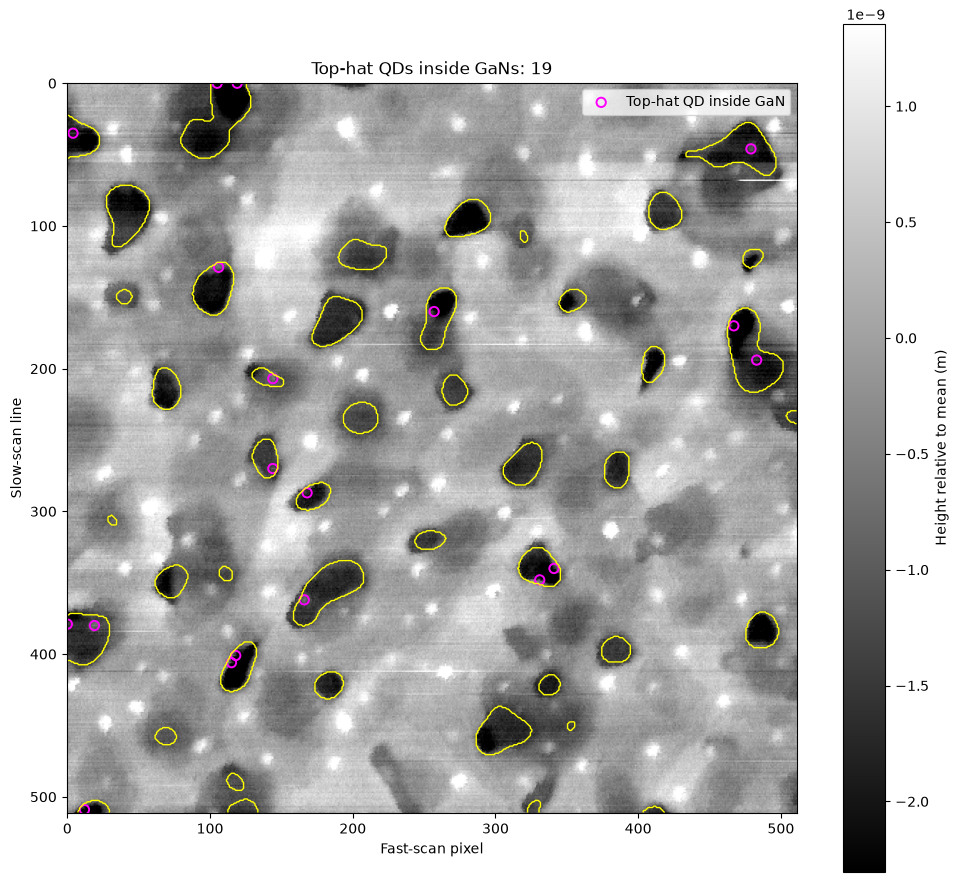

In [40]:
fig, ax = plt.subplots(figsize=(10, 9))

image_display = ax.imshow(
    z_processed,
    cmap="gray",
    vmin=np.nanpercentile( z_processed, 1,),
    vmax=np.nanpercentile( z_processed, 99, ),
)

ax.contour(GaN_mask, levels=[0.5], colors="yellow", linewidths=1.0,) #level 0.5 is the standard contour value used for evaluating the contour along a binary mask 

ax.scatter(
    inside_qd_x,
    inside_qd_y,
    s=45,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.4,
    label="Top-hat QD inside GaN",
)

ax.set_title(
    f"Top-hat QDs inside GaNs: "
    f"{len(inside_qd_y)}"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")

fig.colorbar( image_display, ax=ax, label="Height relative to mean (m)",)

ax.legend()
plt.tight_layout()
plt.show()

**4. Detecting QDs outside of the GaN layer, so these QDs will be on the InGaN layer:**

In [41]:
# Detect top-hat QDs outside GaNs

outside_mask = (~GaN_membership_mask & np.isfinite(z_processed))

tophat_outside_GaNs = np.where(outside_mask, tophat_map, 0.0,)

outside_values = tophat_outside_GaNs[outside_mask]
outside_values = outside_values[np.isfinite(outside_values)]

outside_tophat_threshold = np.nanpercentile(outside_values, 85,)

candidate_peaks_outside = peak_local_max(
    tophat_outside_GaNs,
    min_distance=3,
    threshold_abs=outside_tophat_threshold,
    exclude_border=False,
    labels=outside_mask.astype(np.uint8),
)

print("Top-hat candidates outside GaNs:", len(candidate_peaks_outside),)

Top-hat candidates outside GaNs: 1773


**5.  Validate outside candidates by local height**

In [42]:
minimum_dot_height = 6e-10

peak_radius = 2
ring_inner_radius = 3
ring_outer_radius = 7

outside_qd_y = []
outside_qd_x = []
outside_qd_heights = []


for candidate_y, candidate_x in candidate_peaks_outside:

    # Candidate must remain outside GaNs
    if GaN_membership_mask[candidate_y, candidate_x,]:
        continue

    y0 = max(0, candidate_y - ring_outer_radius,)
    y1 = min(z_processed.shape[0], candidate_y + ring_outer_radius + 1,)

    x0 = max(0, candidate_x - ring_outer_radius,)
    x1 = min(z_processed.shape[1], candidate_x + ring_outer_radius + 1,)

    local_height = z_processed[y0:y1, x0:x1,]
    local_membership = GaN_membership_mask[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]
    rr2 = ((yy - candidate_y) ** 2 + (xx - candidate_x) ** 2)

    peak_mask = (rr2 <= peak_radius**2)

    ring_mask = ((rr2 >= ring_inner_radius**2) & (rr2 <= ring_outer_radius**2))

    # Use only non-GaN pixels for the outside background.
    outside_background_ring = (ring_mask & (~local_membership))

    peak_values = local_height[peak_mask]
    background_values = local_height[outside_background_ring]
    peak_values = peak_values[np.isfinite(peak_values)]
    background_values = background_values[np.isfinite(background_values)]

    if (peak_values.size == 0 or background_values.size < 8):
        continue

    local_peak = np.nanmax(peak_values)
    local_background = np.nanmedian(background_values)
    local_dot_height = (local_peak - local_background)

    if local_dot_height >= minimum_dot_height:
        outside_qd_y.append(candidate_y)
        outside_qd_x.append(candidate_x)
        outside_qd_heights.append(local_dot_height)


outside_qd_y = np.asarray(outside_qd_y, dtype=int,)
outside_qd_x = np.asarray(outside_qd_x, dtype=int,)

outside_qd_heights = np.asarray(outside_qd_heights, dtype=float,)

print("Accepted QDs outside GaNs:", len(outside_qd_y),)

if len(outside_qd_heights) > 0:
    print("Median outside QD height:", np.median(outside_qd_heights) * 1e9,"nm",)

Accepted QDs outside GaNs: 168
Median outside QD height: 0.8876691666319878 nm


**6. Plot inside QDs in pink and outside QDs in orange**

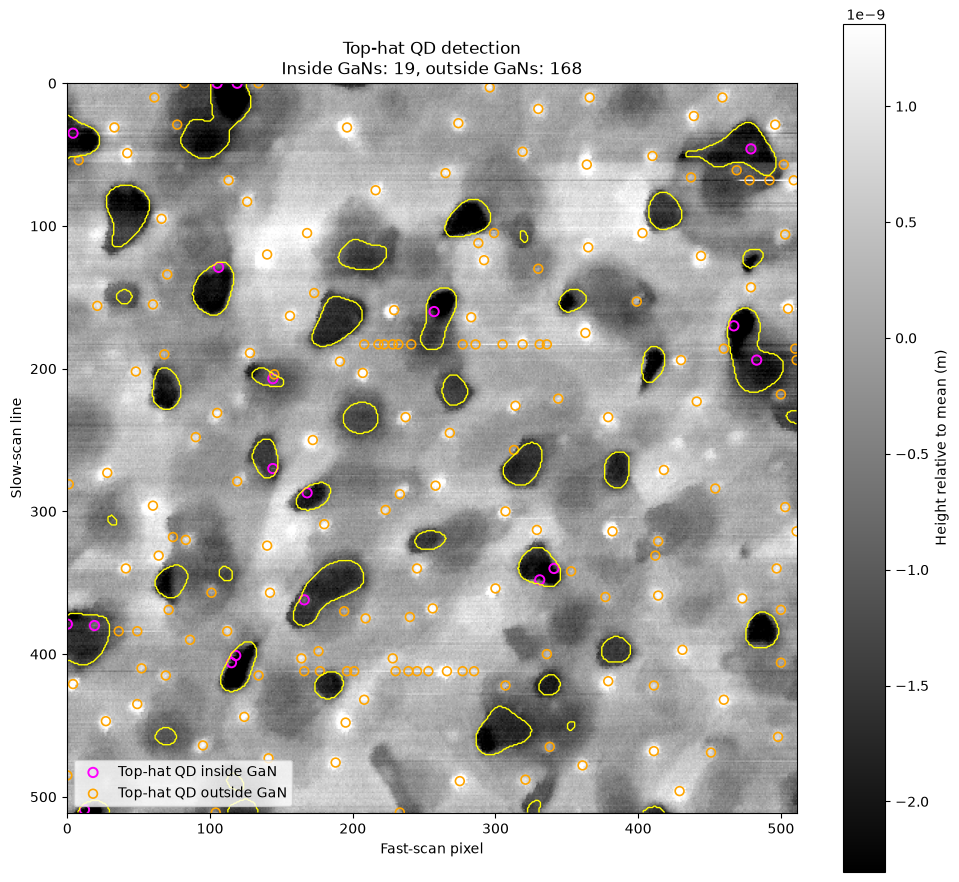

In [43]:
fig, ax = plt.subplots(
    figsize=(10, 9)
)

image_display = ax.imshow(
    z_processed,
    cmap="gray",
    vmin=np.nanpercentile( z_processed, 1,),
    vmax=np.nanpercentile( z_processed, 99, ),
)

ax.contour(GaN_mask, levels=[0.5], colors="yellow", linewidths=1.0,)

# Inside-GaN QDs
ax.scatter(
    inside_qd_x,
    inside_qd_y,
    s=45,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.4,
    label="Top-hat QD inside GaN",
)

# Outside-GaN QDs
ax.scatter(
    outside_qd_x,
    outside_qd_y,
    s=40,
    facecolors="none",
    edgecolors="orange",
    linewidths=1.2,
    label="Top-hat QD outside GaN",
)

ax.set_title(
    f"Top-hat QD detection\n"
    f"Inside GaNs: {len(inside_qd_y)}, "
    f"outside GaNs: {len(outside_qd_y)}"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")
fig.colorbar( image_display, ax=ax, label="Height relative to mean (m)",)
ax.legend()
plt.tight_layout()
plt.show()

Now, since we have 2 classes, we can compare if dots on GaN layer and dots on the InGaN layer are morphologically different. 

**To do this, lets compare:**
* local height above surrounding surface
* full width at half maximum in x and y
* equivalent diameter
* area above a relative-height threshold
* aspect ratio
* eccentricity
* circularity
* top-hat response strength
* local GaN depth for inside-GaN dots

# Comparing and Analysing QDs on GaN and InGaN layers

In [44]:
import numpy as np
import pandas as pd

from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects

In [45]:
geometry_radius = 8

# Segment each dot at this fraction of its local peak height.
relative_contour_fraction = 0.50
minimum_segment_area = 3

# Combine both QD classes
all_qd_y = np.concatenate([inside_qd_y, outside_qd_y,])
all_qd_x = np.concatenate([inside_qd_x, outside_qd_x,])

all_qd_class = np.concatenate(
    [
        np.full(len(inside_qd_y), "inside_GaN", dtype=object,),
        np.full(len(outside_qd_y), "outside_GaN",dtype=object,),
    ]
)

**1. Measure the selected properties of each QD**

In [46]:
# Measure each QD
qd_features = []

for qd_id, (centre_y, centre_x, qd_class,) in enumerate(
    zip(all_qd_y, all_qd_x, all_qd_class,), start=1,):

    y0 = max(0, centre_y - geometry_radius,)
    y1 = min(z_processed.shape[0], centre_y + geometry_radius + 1,)

    x0 = max(0, centre_x - geometry_radius,)
    x1 = min(z_processed.shape[1], centre_x + geometry_radius + 1,)

    patch = z_processed[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]
    rr2 = ((yy - centre_y) ** 2 + (xx - centre_x) ** 2)

    background_ring = ((rr2 >= 5**2) & (rr2 <= geometry_radius**2))
    background_values = patch[background_ring]
    background_values = background_values[np.isfinite(background_values)]

    if background_values.size < 10:
        continue

    local_background = np.nanmedian(background_values)
    local_patch = (patch - local_background)
    local_peak = np.nanmax(local_patch)

    if (not np.isfinite(local_peak) or local_peak <= 0):
        continue

    contour_level = (relative_contour_fraction * local_peak)

    dot_binary = (local_patch >= contour_level)
    dot_binary = remove_small_objects(dot_binary, min_size=minimum_segment_area,)
    dot_labels = label(dot_binary)

    local_centre_y = (centre_y - y0)
    local_centre_x = (centre_x - x0)
    dot_label_at_centre = dot_labels[local_centre_y, local_centre_x,]

    # If the exact centre is not segmented, use the nearest segmented component to the detected peak.
    if dot_label_at_centre == 0:
        regions = regionprops(dot_labels)
        if len(regions) == 0:
            continue

        distances = []

        for region in regions:
            region_y, region_x = (region.centroid)
            distance = np.hypot(region_y - local_centre_y, region_x - local_centre_x,)
            distances.append(distance)

        selected_region = regions[np.argmin(distances)]

    else:
        selected_region = regionprops(dot_labels)[dot_label_at_centre - 1]


    area_pixels = selected_region.area
    equivalent_diameter = (selected_region.equivalent_diameter_area)
    major_axis = (selected_region.axis_major_length)
    minor_axis = (selected_region.axis_minor_length)
    eccentricity = (selected_region.eccentricity)
    perimeter = (selected_region.perimeter)

    if perimeter > 0:
        circularity = (4 * np.pi * area_pixels / perimeter**2)
    else:
        circularity = np.nan

    if minor_axis > 0:
        aspect_ratio = (major_axis / minor_axis)
    else:
        aspect_ratio = np.nan


    # Estimate FWHM directly from horizontal profile
    horizontal_profile = local_patch[local_centre_y,:]
    vertical_profile = local_patch[:, local_centre_x,]

    half_height = (0.5 * local_peak)

    horizontal_above = np.where(horizontal_profile >= half_height)[0]
    vertical_above = np.where(vertical_profile >= half_height)[0]

    if horizontal_above.size > 0:
        fwhm_x_pixels = (horizontal_above[-1] - horizontal_above[0] + 1)

    else:
        fwhm_x_pixels = np.nan

    if vertical_above.size > 0:
        fwhm_y_pixels = (vertical_above[-1] - vertical_above[0] + 1)

    else:
        fwhm_y_pixels = np.nan


    qd_features.append(
        {
            "qd_id": qd_id,
            "class": qd_class,
            "centre_y": centre_y,
            "centre_x": centre_x,
            "height_m": local_peak,
            "height_nm": local_peak * 1e9,
            "area_pixels": area_pixels,
            "equivalent_diameter_pixels":
                equivalent_diameter,
            "major_axis_pixels":
                major_axis,
            "minor_axis_pixels":
                minor_axis,
            "aspect_ratio":
                aspect_ratio,
            "eccentricity":
                eccentricity,
            "perimeter_pixels":
                perimeter,
            "circularity":
                circularity,
            "fwhm_x_pixels":
                fwhm_x_pixels,
            "fwhm_y_pixels":
                fwhm_y_pixels,
        }
    )

qd_feature_table = pd.DataFrame(qd_features)

print(qd_feature_table.head())
print("\nNumber of measured QDs by class:")
print(qd_feature_table["class"].value_counts())

   qd_id       class  centre_y  centre_x      height_m  height_nm  \
0      1  inside_GaN         0       119  2.718161e-09   2.718161   
1      2  inside_GaN        46       479  8.631684e-10   0.863168   
2      4  inside_GaN       380        19  9.911042e-10   0.991104   
3      5  inside_GaN       362       166  1.722260e-09   1.722260   
4      6  inside_GaN         0       105  1.860350e-09   1.860350   

   area_pixels  equivalent_diameter_pixels  major_axis_pixels  \
0         26.0                    5.753627           9.457570   
1         26.0                    5.753627           7.028784   
2         21.0                    5.170883           6.570738   
3         36.0                    6.770275          11.046253   
4         56.0                    8.444016          10.759865   

   minor_axis_pixels  aspect_ratio  eccentricity  perimeter_pixels  \
0           4.886698      1.935370      0.856168         19.449747   
1           5.556998      1.264853      0.612325      

2542962837.py (35): Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.


**2. Comparing the QD parameters**

In [47]:
summary_table = (
    qd_feature_table
    .groupby("class")
    [
        [
            "height_nm",
            "area_pixels",
            "equivalent_diameter_pixels",
            "major_axis_pixels",
            "minor_axis_pixels",
            "aspect_ratio",
            "eccentricity",
            "circularity",
            "fwhm_x_pixels",
            "fwhm_y_pixels",
        ]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
        ]
    )
)

print(summary_table)

            height_nm                               area_pixels             \
                count      mean    median       std       count       mean   
class                                                                        
inside_GaN         18  1.689387  1.794086  0.744149          18  52.888889   
outside_GaN       164  1.186406  1.100430  0.444946         164  30.932927   

                              equivalent_diameter_pixels            ...  \
            median        std                      count      mean  ...   
class                                                               ...   
inside_GaN    38.0  35.386752                         18  7.776002  ...   
outside_GaN   31.0  16.515147                        164  6.027705  ...   

            circularity           fwhm_x_pixels                             \
                 median       std         count      mean median       std   
class                                                                        

**Height Distributions**

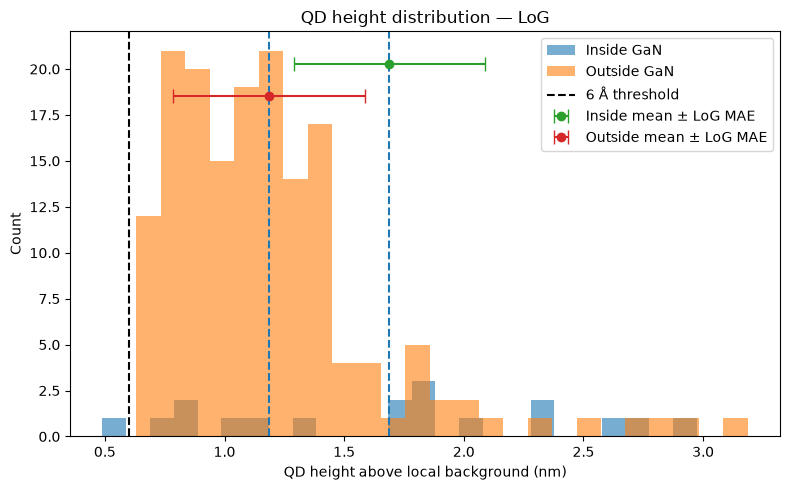

In [48]:
import numpy as np
import matplotlib.pyplot as plt


inside_heights = qd_feature_table.loc[
    qd_feature_table["class"] == "inside_GaN",
    "height_nm",
].to_numpy()

outside_heights = qd_feature_table.loc[
    qd_feature_table["class"] == "outside_GaN",
    "height_nm",
].to_numpy()


# FROM YOUR LoG ERROR TABLE
log_height_mae_nm = 0.40      # replace with actual number


inside_mean = np.mean(inside_heights)
outside_mean = np.mean(outside_heights)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    inside_heights,
    bins=25,
    alpha=0.6,
    label="Inside GaN",
)

ax.hist(
    outside_heights,
    bins=25,
    alpha=0.6,
    label="Outside GaN",
)


# 6 Å HEIGHT THRESHOLD
ax.axvline(
    0.6,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="6 Å threshold",
)


# MEAN HEIGHTS
ax.axvline(
    inside_mean,
    linestyle="--",
    linewidth=1.5,
)

ax.axvline(
    outside_mean,
    linestyle="--",
    linewidth=1.5,
)


# ERROR BARS
ymax = ax.get_ylim()[1]

ax.errorbar(
    inside_mean,
    ymax * 0.92,
    xerr=log_height_mae_nm,
    fmt="o",
    capsize=5,
    label=f"Inside mean ± LoG MAE",
)

ax.errorbar(
    outside_mean,
    ymax * 0.84,
    xerr=log_height_mae_nm,
    fmt="o",
    capsize=5,
    label=f"Outside mean ± LoG MAE",
)


ax.set_xlabel(
    "QD height above local background (nm)"
)

ax.set_ylabel(
    "Count"
)

ax.set_title(
    "QD height distribution — LoG"
)

ax.legend()

plt.tight_layout()
plt.show()

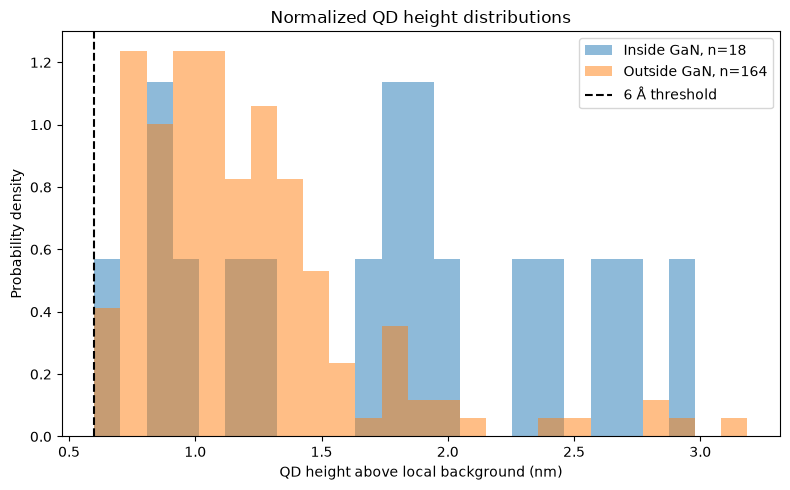

Minimum height in table: 0.489887360449593 nm
Dots below 0.6 nm: 1


In [49]:
inside_heights_nm = qd_feature_table.loc[
    qd_feature_table["class"] == "inside_GaN",
    "height_nm",
]

outside_heights_nm = qd_feature_table.loc[
    qd_feature_table["class"] == "outside_GaN",
    "height_nm",
]


fig, ax = plt.subplots(
    figsize=(8, 5)
)

common_bins = np.linspace(
    0.6,
    max(
        inside_heights_nm.max(),
        outside_heights_nm.max(),
    ),
    26,
)

ax.hist(
    inside_heights_nm,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Inside GaN, n={len(inside_heights_nm)}",
)

ax.hist(
    outside_heights_nm,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Outside GaN, n={len(outside_heights_nm)}",
)

ax.axvline(
    0.6,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="6 Å threshold",
)

ax.set_xlabel(
    "QD height above local background (nm)"
)

ax.set_ylabel(
    "Probability density"
)

ax.set_title(
    "Normalized QD height distributions"
)

ax.legend()

plt.tight_layout()
plt.show()

print(
    "Minimum height in table:",
    qd_feature_table["height_nm"].min(),
    "nm",
)

print(
    "Dots below 0.6 nm:",
    np.sum(
        qd_feature_table["height_nm"] < 0.6
    ),
)

**Width distribution**

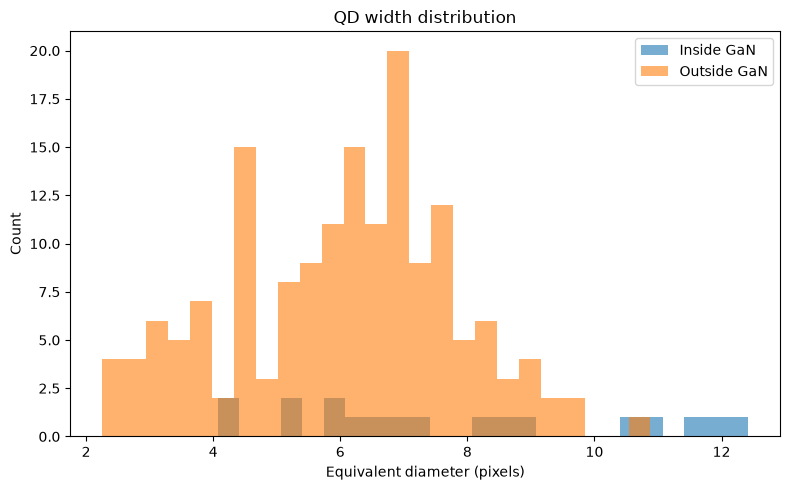

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"]
        == "inside_GaN",
        "equivalent_diameter_pixels",
    ],
    bins=25,
    alpha=0.6,
    label="Inside GaN",
)

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"]
        == "outside_GaN",
        "equivalent_diameter_pixels",
    ],
    bins=25,
    alpha=0.6,
    label="Outside GaN",
)

ax.set_xlabel("Equivalent diameter (pixels)")
ax.set_ylabel("Count")
ax.set_title("QD width distribution")
ax.legend()

plt.tight_layout()
plt.show()

**Height vs. Width**

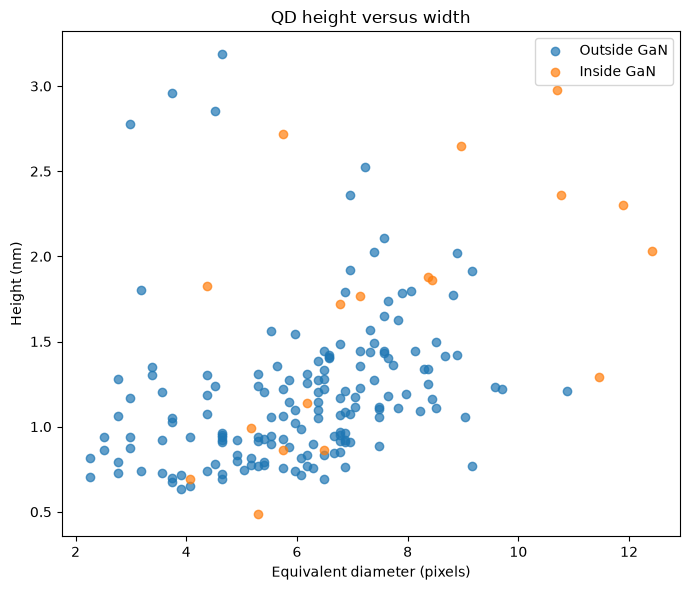

In [51]:
fig, ax = plt.subplots(figsize=(7, 6))

inside_rows = (qd_feature_table["class"] == "inside_GaN")
outside_rows = (qd_feature_table["class"] == "outside_GaN")

ax.scatter(
    qd_feature_table.loc[outside_rows, "equivalent_diameter_pixels",],
    qd_feature_table.loc[outside_rows, "height_nm",],
    alpha=0.7,
    label="Outside GaN",
)

ax.scatter(
    qd_feature_table.loc[inside_rows, "equivalent_diameter_pixels",],
    qd_feature_table.loc[inside_rows, "height_nm",],
    alpha=0.7,
    label="Inside GaN",
)

ax.set_xlabel("Equivalent diameter (pixels)")
ax.set_ylabel("Height (nm)")
ax.set_title("QD height versus width")
ax.legend()

plt.tight_layout()
plt.show()

In [52]:
inside_radii = qd_feature_table.loc[
    qd_feature_table["class"] == "inside_GaN",
    "radius_px",
]

outside_radii = qd_feature_table.loc[
    qd_feature_table["class"] == "outside_GaN",
    "radius_px",
]

log_radius_mean_error_px = 0.8907

fig, ax = plt.subplots(figsize=(8, 5))

common_bins = np.linspace(
    min(inside_radii.min(), outside_radii.min()),
    max(inside_radii.max(), outside_radii.max()),
    26,
)

ax.hist(
    inside_radii,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Inside GaN, n={len(inside_radii)}",
)

ax.hist(
    outside_radii,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Outside GaN, n={len(outside_radii)}",
)

inside_mean = inside_radii.mean()
outside_mean = outside_radii.mean()

ymax = ax.get_ylim()[1]

ax.errorbar(
    inside_mean,
    ymax * 0.92,
    xerr=log_radius_mean_error_px,
    fmt="o",
    capsize=5,
    label="Inside mean ± LoG radius error",
)

ax.errorbar(
    outside_mean,
    ymax * 0.84,
    xerr=log_radius_mean_error_px,
    fmt="o",
    capsize=5,
    label="Outside mean ± LoG radius error",
)

ax.set_xlabel("QD radius (px)")
ax.set_ylabel("Probability density")
ax.set_title("Normalized QD radius distributions — LoG")
ax.legend()

plt.tight_layout()
plt.show()

KeyError: 'radius_px'